# State-Space Time2Success Dataset Collection

Collects **successful-only** trajectories from the **final trained policy**,
capturing the observation vector (state space) + timestamp-derived
temporal-distance labels per frame. No vision, no video, no checkpoint
diversity — deliberately narrow scope matching what was asked. See the
reminders section at the end for what this scope leaves out.

## 1. Setup and sanity checks

In [2]:
import gymnasium as gym
import metaworld
import numpy as np
import os, json
from stable_baselines3 import SAC

TASK_NAME = "peg-insert-side-v3"
SUCCESS_KEY = "success"

def make_env(seed=0, render_mode=None):
    return gym.make("Meta-World/MT1", env_name=TASK_NAME, seed=seed, render_mode=render_mode)

_probe = make_env(seed=0)
DT = getattr(_probe.unwrapped, "dt", _probe.unwrapped.model.opt.timestep)
OBS_DIM = _probe.observation_space.shape[0]
_probe.close()

print("DT (seconds per step):", DT)
print("Observation dim:", OBS_DIM)  # confirms MLP input size before building anything

DT (seconds per step): 0.0125
Observation dim: 39


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")


## 2. Load the final trained policy

In [ ]:
FINAL_CKPT = "./checkpoints/peg_insert_side/sac_peg_insert_final"
model = SAC.load(FINAL_CKPT)
print("Loaded:", FINAL_CKPT)

2.b Load all trained policy and select the successful traj from them

In [3]:
# Section 2 — load multiple checkpoints spanning training progress, not just final
import glob

checkpoint_paths = sorted(
    glob.glob("./checkpoints/peg_insert_side/sac_peg_insert_*.zip"),
    key=lambda p: int(''.join(filter(str.isdigit, os.path.basename(p)))) if any(c.isdigit() for c in os.path.basename(p)) else 0
)
FINAL_CKPT = "./checkpoints/peg_insert_side/sac_peg_insert_final"
selected_checkpoints = list(dict.fromkeys(
    [checkpoint_paths[0], checkpoint_paths[len(checkpoint_paths)//2], checkpoint_paths[-1]]
))
print("Using checkpoints:", selected_checkpoints)

Using checkpoints: ['./checkpoints/peg_insert_side\\sac_peg_insert_final.zip', './checkpoints/peg_insert_side\\sac_peg_insert_400000.zip', './checkpoints/peg_insert_side\\sac_peg_insert_700000.zip']


## 3. Collection function

Rolls out one episode deterministically, capturing `obs` at every step.
Returns `None` for the whole episode if it didn't succeed — filtering happens
at the call site, not here, so this function stays reusable if you ever want
failed episodes too.

In [4]:
def collect_episode_state(model, env, deterministic=True, max_steps=500,
                           extra_frames_after_success=None):
    obs, _ = env.reset()
    obs_list = []
    success_step = None
    frames_since_success = 0
    for t in range(max_steps):
        obs_list.append(obs.copy())
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(action)
        if info.get(SUCCESS_KEY, 0) and success_step is None:
            success_step = t

        # NEW: don't stop at success — keep going a bit longer so the
        # dataset actually contains "task already done" states.
        if success_step is not None and extra_frames_after_success is not None:
            frames_since_success += 1
            if frames_since_success >= extra_frames_after_success:
                break
        if terminated or truncated:
            break
    return obs_list, success_step

## 5. Full collection — successful trajectories only

Since only successes are kept, and this uses a single (final, competent)
policy, most seeds should succeed — but not all. The loop below keeps
trying new seeds until it collects `TARGET_SUCCESSFUL_EPISODES`, rather than
running a fixed seed count and hoping enough succeed.

In [ ]:
TARGET_SUCCESSFUL_EPISODES = 100
MAX_SEED_ATTEMPTS = TARGET_SUCCESSFUL_EPISODES * 3
EXTRA_FRAMES_AFTER_SUCCESS = 30  # ~0.375s of settled post-success motion at DT=0.0125

episodes = []
seed = 0
attempts = 0

while len(episodes) < TARGET_SUCCESSFUL_EPISODES and attempts < MAX_SEED_ATTEMPTS:
    env = make_env(seed=seed)
    obs_list, success_step = collect_episode_state(
        model, env, extra_frames_after_success=EXTRA_FRAMES_AFTER_SUCCESS)
    env.close()
    attempts += 1

    if success_step is not None:
        episodes.append(dict(obs_list=obs_list, success_step=success_step, seed=seed))
        if len(episodes) % 20 == 0:
            print(f"[{len(episodes)}/{TARGET_SUCCESSFUL_EPISODES}] collected "
                  f"(seed={seed}, attempts so far={attempts})")
    seed += 1

# NEW: check spread of success timing — a narrow spread here was the
# under-noticed signal behind the low-diversity-manifold issue flagged earlier.
success_steps_all = [ep["success_step"] for ep in episodes]
print(f"\nDone: {len(episodes)} successful episodes from {attempts} attempts")
print(f"success_step range: min={min(success_steps_all)}, max={max(success_steps_all)}, "
      f"mean={np.mean(success_steps_all):.1f}, std={np.std(success_steps_all):.1f}")
if np.std(success_steps_all) < 5:
    print("WARNING: very narrow spread — episodes may be too homogeneous "
          "(see earlier discussion on low-diversity training data).")

5.b Various Policy Collection

In [5]:
TARGET_SUCCESSFUL_EPISODES = 100
MAX_SEED_ATTEMPTS = TARGET_SUCCESSFUL_EPISODES * 3

# Section 5 — collect from each checkpoint, tagging source so you can inspect diversity later
episodes = []
seed = 0
EPISODES_PER_CHECKPOINT = 40  # ~4x the checkpoints -> larger, more varied dataset

for ckpt_path in selected_checkpoints:
    ckpt_model = SAC.load(ckpt_path)
    collected_this_ckpt = 0
    attempts_this_ckpt = 0
    while collected_this_ckpt < EPISODES_PER_CHECKPOINT and attempts_this_ckpt < EPISODES_PER_CHECKPOINT * 3:
        env = make_env(seed=seed)
        obs_list, success_step = collect_episode_state(
            ckpt_model, env, extra_frames_after_success=None)
        env.close()
        attempts_this_ckpt += 1
        seed += 1
        if success_step is not None:
            episodes.append(dict(obs_list=obs_list, success_step=success_step,
                                   seed=seed, source_ckpt=os.path.basename(ckpt_path)))
            collected_this_ckpt += 1
    print(f"{os.path.basename(ckpt_path)}: {collected_this_ckpt}/{EPISODES_PER_CHECKPOINT} collected")

success_steps_all = [ep["success_step"] for ep in episodes]
print(f"\nTotal episodes: {len(episodes)}")
print(f"success_step spread: min={min(success_steps_all)}, max={max(success_steps_all)}, "
      f"std={np.std(success_steps_all):.1f}")  # should be MUCH wider than before now

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


sac_peg_insert_final.zip: 40/40 collected
sac_peg_insert_400000.zip: 40/40 collected
sac_peg_insert_700000.zip: 40/40 collected

Total episodes: 120
success_step spread: min=41, max=255, std=36.2


## 6. Build (state, label) rows with temporal-distance labels

Two label units kept side by side (steps and seconds) — use whichever
the training script expects; steps is the more numerically stable target,
seconds is more interpretable.

In [28]:
records = []

for ep_idx, ep in enumerate(episodes):
    success_step = ep["success_step"]
    obs_list = ep["obs_list"]  # now includes post-success frames too

    for t, obs in enumerate(obs_list):
        # KEY CHANGE: clip at 0 instead of stopping the loop at success_step.
        # Frames at/after success get label 0 — "task is done" is itself
        # accurate, useful information the model never saw before.
        steps_remaining = max(0, success_step - t)
        records.append(dict(
            episode_idx=ep_idx,
            seed=ep["seed"],
            frame_idx=t,
            timestamp_sec=round(t * DT, 4),
            steps_remaining=steps_remaining,
            seconds_remaining=round(steps_remaining * DT, 4),
            obs=obs.tolist(),
        ))

print(f"Total (state, label) rows: {len(records)}")
n_post_success = sum(1 for ep in episodes for t in range(len(ep["obs_list"])) if t > ep["success_step"])
print(f"Post-success rows included: {n_post_success} (previously: 0)")

Total (state, label) rows: 60000
Post-success rows included: 51409 (previously: 0)


In [6]:
HAND_POS_IDX = [0, 1, 2]
GRIPPER_IDX  = 3
PEG_POS_IDX  = [4, 5, 6]
GOAL_POS_IDX = [36, 37, 38]
GRIPPER_CLOSED_THRESHOLD = 0.6   # openness runs 1.0 (open) -> ~0.28 (closed)

records = []

for ep_idx, ep in enumerate(episodes):
    success_step = ep["success_step"]
    obs_list = ep["obs_list"]

    for t, obs in enumerate(obs_list):
        hand = obs[HAND_POS_IDX]
        peg  = obs[PEG_POS_IDX]
        goal = obs[GOAL_POS_IDX]
        gripper = obs[GRIPPER_IDX]

        hand_to_peg = np.linalg.norm(hand - peg)
        peg_to_goal = np.linalg.norm(peg - goal)
        # "holding" = gripper closed AND hand is at the peg
        holding = float(gripper < GRIPPER_CLOSED_THRESHOLD and hand_to_peg < 0.06)

        records.append(dict(
            episode_idx=ep_idx,
            seed=ep["seed"],
            frame_idx=t,
            steps_remaining=max(0, success_step - t),
            seconds_remaining=round(max(0, success_step - t) * DT, 4),
            obs=obs.tolist(),
            hand_to_peg=float(hand_to_peg),
            peg_to_goal=float(peg_to_goal),
            gripper=float(gripper),
            holding=holding,
            hand_to_peg_vec=(peg - hand).tolist(),   # relative offsets, not just magnitudes
            peg_to_goal_vec=(goal - peg).tolist(),
        ))

print(f"Total rows: {len(records)}")

Total rows: 60000


## 7. Save the dataset

In [7]:
import numpy as np

OUTPUT_DIR = "./data/state_space_datasetV5"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save as numpy arrays for fast loading in the training notebook
X = np.array([r["obs"] for r in records], dtype=np.float32)
y_steps = np.array([r["steps_remaining"] for r in records], dtype=np.float32)
y_seconds = np.array([r["seconds_remaining"] for r in records], dtype=np.float32)
episode_ids = np.array([r["episode_idx"] for r in records], dtype=np.int32)  # for group-aware splitting

np.savez(
    os.path.join(OUTPUT_DIR, "dataset.npz"),
    X=X, y_steps=y_steps, y_seconds=y_seconds, episode_ids=episode_ids,
)

# Derive facts from what's actually in `episodes`, not from variables that
# may be stale or out of sync with what the collection loop actually did.
avg_frames_per_episode = len(records) / len(episodes)
sources_used = sorted(set(ep.get("source_ckpt", FINAL_CKPT) for ep in episodes))

summary = dict(
    total_rows=len(records),
    total_episodes=len(episodes),
    obs_dim=int(OBS_DIM),
    dt_sec=DT,
    sources_used=sources_used,                          # actual list, not an assumption
    checkpoint_diversity=len(sources_used) > 1,          # derived, not hardcoded
    successful_only=True,
    avg_frames_per_episode=round(avg_frames_per_episode, 1),  # sanity check built in
    success_step_min=int(min(success_steps_all)),
    success_step_max=int(max(success_steps_all)),
    success_step_std=float(np.std(success_steps_all)),
)
with open(os.path.join(OUTPUT_DIR, "dataset_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("Saved to:", os.path.abspath(OUTPUT_DIR))
print(summary)
print(f"\nSanity check: avg_frames_per_episode = {avg_frames_per_episode:.1f} "
      f"(~500 if uncapped post-success collection actually ran, ~58 if still old-style capped)")

Saved to: e:\@ML_Projects\Peg_insertion\data\state_space_datasetV5
{'total_rows': 60000, 'total_episodes': 120, 'obs_dim': 39, 'dt_sec': 0.0125, 'sources_used': ['sac_peg_insert_400000.zip', 'sac_peg_insert_700000.zip', 'sac_peg_insert_final.zip'], 'checkpoint_diversity': True, 'successful_only': True, 'avg_frames_per_episode': 500.0, 'success_step_min': 41, 'success_step_max': 255, 'success_step_std': 36.21843357401802}

Sanity check: avg_frames_per_episode = 500.0 (~500 if uncapped post-success collection actually ran, ~58 if still old-style capped)


In [8]:
X = np.array([r["obs"] for r in records], dtype=np.float32)

# Derived features, kept separate so you can train with obs-only or obs+derived
X_derived = np.array([
    r["hand_to_peg_vec"] + r["peg_to_goal_vec"] + [r["hand_to_peg"], r["peg_to_goal"],
                                                     r["gripper"], r["holding"]]
    for r in records
], dtype=np.float32)   # 3 + 3 + 4 = 10 columns

y_steps = np.array([r["steps_remaining"] for r in records], dtype=np.float32)
episode_ids = np.array([r["episode_idx"] for r in records], dtype=np.int32)
holding_flags = np.array([r["holding"] for r in records], dtype=np.float32)

np.savez(os.path.join(OUTPUT_DIR, "dataset.npz"),
         X=X, X_derived=X_derived, y_steps=y_steps,
         episode_ids=episode_ids, holding_flags=holding_flags)

In [9]:
d = np.load(os.path.join(OUTPUT_DIR, "dataset.npz"))
X_der, hold, eps, ys = d["X_derived"], d["holding_flags"], d["episode_ids"], d["y_steps"]

print(f"X_derived shape: {X_der.shape}  (expect 10 columns)")
print(f"holding=1 rows: {hold.sum():.0f} / {len(hold)} ({100*hold.mean():.1f}%)")

X_derived shape: (60000, 10)  (expect 10 columns)
holding=1 rows: 35056 / 60000 (58.4%)


In [10]:
# Does grasp occur exactly once per episode, at a sensible time?
grasp_frames = []
for ep in np.unique(eps):
    m = eps == ep
    h = hold[m]
    onsets = np.where(np.diff(h) > 0)[0]
    if len(onsets):
        grasp_frames.append(onsets[0])
    print(f"ep {ep}: grasp at frame {onsets[0] if len(onsets) else None}, "
          f"transitions={len(onsets)}, ep_len={m.sum()}") if ep < 5 else None

grasp_frames = np.array(grasp_frames)
print(f"\nEpisodes with a detected grasp: {len(grasp_frames)}/{len(np.unique(eps))}")
print(f"Grasp frame: mean={grasp_frames.mean():.1f}, min={grasp_frames.min()}, max={grasp_frames.max()}")

ep 0: grasp at frame 24, transitions=1, ep_len=500
ep 1: grasp at frame 25, transitions=1, ep_len=500
ep 2: grasp at frame 22, transitions=1, ep_len=500
ep 3: grasp at frame 61, transitions=1, ep_len=500
ep 4: grasp at frame 23, transitions=1, ep_len=500

Episodes with a detected grasp: 119/120
Grasp frame: mean=31.5, min=21, max=63


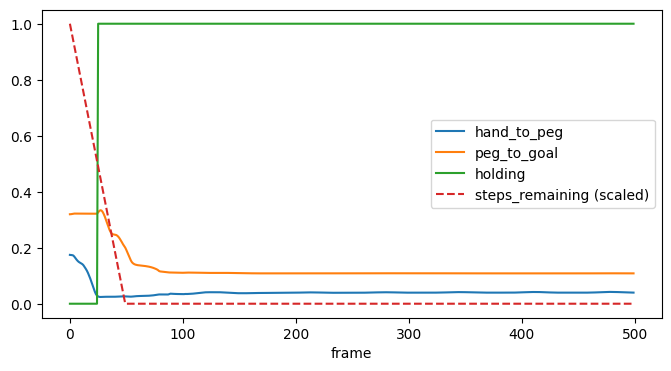

In [11]:
# Sanity: do the derived distances behave as the task implies?
ep0 = eps == 0
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(X_der[ep0, 6], label="hand_to_peg")
ax.plot(X_der[ep0, 7], label="peg_to_goal")
ax.plot(X_der[ep0, 9], label="holding")
ax.plot(ys[ep0] / ys[ep0].max(), "--", label="steps_remaining (scaled)")
ax.set_xlabel("frame"); ax.legend(); plt.show()

## 8. Reminders — what this scope leaves out

Read before treating this dataset as final:

- **Successful-only, single-policy source.** No failure/regression coverage
  (unlike the earlier checkpoint-diversity discussion) — this dataset
  will only ever describe states along near-optimal trajectories. Fine for
  a first pass, but revisit if the trained regressor needs to handle
  off-distribution states later (e.g., for reward shaping a *different*,
  less-mature policy).
- **`obs` composition not yet verified.** Step 1 prints `OBS_DIM` but doesn't
  confirm whether velocity is included, only position — worth checking
  MetaWorld's docs/source for this task if the MLP-vs-RNN question ever
  comes back up.
- **`TARGET_SUCCESSFUL_EPISODES=100` is a starting guess**, not a validated
  sufficient size — same caution as the "small amount of data" discussion
  earlier: treat a first training run on this as a pipeline smoke test, not
  a final result.
- **Group-aware splitting still needed at training time** —
  `episode_ids` is saved specifically so the training script can split by
  episode, not by row, avoiding the leakage issue flagged in stage 2.
- **The stage-2 training script assumed the video/embedding dataset format**
  — it needs updating to load this `.npz` format and use a plain MLP on
  `X` directly instead of the frozen-encoder embedding step. Worth doing as
  the next piece.